## Laborbuch – Szenario 1

Dieses Notebook untersucht die Messdaten des Szenario mit dauerhaft aktiven Knoten. In diesem Szenario sind alle ausgewählten Knoten über die gesamte Messdauer hinweg gleichzeitig aktiv. Es gibt keinen zeitlichen Staffelungs-Effekt wie beim schrittweisen An- und Abschalten der Knoten oder bei kurzzeitigen Lastspitzen; stattdessen liegt eine konstante, dauerhaft anliegende Netzlast an

Das Ziel der Analyse besteht darin, den Zeitpunkt zu identifizieren, ab dem die konfigurierte Maximalbandbreite $B_\text{max}$ überschritten wird, und das Verhalten des ARC-DSA-Algorithmus (Adaptive Rate Control for Decentralized Sensing Applications) unter diesen Bedingungen zu evaluieren.

- **Titel der Arbeit:** Experimentelle Analyse adaptiver Ratenregelung in Sensornetzwerken
- **Autor:** Vincenzo Auricchio
- **Studiengang:** Informatik (B.Sc.)
- **Fakultät:** Hochschule München, Fakultät für Informatik und Mathematik
- **Datum:** 29. August 2025  

---

## 1.0 Imports

In [113]:
from pathlib import Path
import json
from typing import Dict, List, Any
from datetime import datetime, timezone
import pandas as pd
from typing import Optional
import matplotlib.pyplot as plt

## 1.1 Definition der benötigten Funktionen  

In [114]:
def parse_ts(x):
    """
    Parse a timestamp value into a timezone-aware datetime object.

    This function accepts either:
    - epoch milliseconds (int or float), or
    - ISO 8601 formatted string (optionally with 'Z' suffix for UTC).

    Parameters
    ----------
    x : int, float, or str
        The timestamp value to parse.

    Returns
    -------
    datetime.datetime or None
        Parsed datetime object in UTC timezone if valid, otherwise None.

    Raises
    ------
    None
        Returns None instead of raising an exception for invalid inputs.
    """
    if isinstance(x, (int, float)):
        return datetime.fromtimestamp(x/1000.0, tz=timezone.utc)
    try:
        return datetime.fromisoformat(str(x).replace("Z", "+00:00"))
    except Exception:
        return None


def read_json_file(fp: Path) -> List[dict]:
    """
    Read a JSON file and return its contents as a list of dictionaries.

    Parameters
    ----------
    fp : pathlib.Path
        Path to the JSON file.

    Returns
    -------
    list of dict
        Parsed data if the file contains a JSON array, otherwise an empty list.

    Raises
    ------
    None
        Errors in reading or parsing are caught, and an empty list is returned.
    """
    try:
        data = json.loads(fp.read_text(encoding="utf-8"))
        return data if isinstance(data, list) else []
    except Exception:
        return []


def discover_nodes(root: Path, scenario: str, kind: str) -> List[int]:
    """
    Discover node IDs by scanning subdirectories named 'node-<ID>'.

    Parameters
    ----------
    root : pathlib.Path
        Base path of the dataset.
    scenario : str
        Scenario name (e.g., 'ramp', 'always' or 'burst').
    kind : str
        Data type, usually 'beacon' or 'message'.

    Returns
    -------
    list of int
        Sorted list of discovered node IDs. Empty list if no nodes found.

    Raises
    ------
    None
        Errors in parsing folder names are ignored.
    """
    base = root / scenario / kind
    out = []
    if base.exists():
        for d in sorted(base.iterdir()):
            if d.is_dir() and d.name.startswith("node-"):
                try:
                    out.append(int(d.name.split("-")[1]))
                except Exception:
                    pass
    return out


def _normalize_experiment_id(exp: str) -> str:
    """
    Ensure experiment id is zero-padded like '01', '02', ...
    Accepts '1' or '01' and returns '01'.
    """
    exp = str(exp).strip()
    return exp.zfill(2) if exp.isdigit() else exp


def build_map(root: Path, scenario: str, kind: str, experiment: Optional[str] = None) -> Dict[int, List[dict]]:
    """
    Build a mapping of node IDs to their log entries.

    If 'experiment' is provided (e.g. '01'), only loads <experiment>.json from each node.
    If None, loads all *.json files under each node directory.

    Parameters
    ----------
    root : pathlib.Path
        Base path of the dataset.
    scenario : str
        Scenario name (e.g., 'ramp', 'always', 'burst', 'ramp_adaption', ...).
    kind : str
        Data type, usually 'beacon' or 'message'.
    experiment : str, optional
        Experiment id like '01', '02', '03'. If None, load all jsons.

    Returns
    -------
    dict[int, list[dict]]
        { node_id: [entries...] } sorted by timestamp.
    """
    result: Dict[int, List[dict]] = {}
    nodes = discover_nodes(root, scenario, kind)

    exp_file = _normalize_experiment_id(experiment) + ".json" if experiment is not None else None

    for n in nodes:
        folder = root / scenario / kind / f"node-{n}"
        entries: List[dict] = []

        if exp_file is not None:
            fp = folder / exp_file
            if fp.exists():
                entries.extend(read_json_file(fp))
        else:
            for fp in sorted(folder.glob("*.json")):
                entries.extend(read_json_file(fp))

        # sort entries by timestamp if available
        entries.sort(key=lambda e: parse_ts(e.get("timestamp")))
        result[n] = entries

    return result



def aggregate_to_seconds(node_logs_map):
    """
    Aggregate log entries into 1-second bins (Bytes/s) per node.

    Parameters
    ----------
    node_logs_map : dict of int -> list of dict
        Mapping {node_id: [ {timestamp, sizeBytes, ...}, ... ]}.

    Returns
    -------
    dict of int -> pandas.DataFrame
        Mapping {node_id: DataFrame}, where each DataFrame has:
        - index: datetime (1-second resolution, UTC)
        - column: 'bytes_per_sec' (summed bytes per second)

    Raises
    ------
    None
        Malformed or empty input is ignored gracefully.
    """
    result = {}
    for node_id, logs in node_logs_map.items():
        if not logs:
            continue
        df = pd.DataFrame(logs)
        df["ts"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.set_index("ts")

        per_sec = df["sizeBytes"].resample("1s").sum()
        result[node_id] = per_sec.to_frame(name="bytes_per_sec")
    return result

def compute_rolling_bytes_per_sec(M: pd.DataFrame, window_s: int = 5) -> pd.DataFrame:
    """
    Compute rolling average throughput over `window_s` seconds.
    
    Parameters
    ----------
    M : pandas.DataFrame
        DataFrame with per-node Bytes/s (1s resolution).
    window_s : int
        Rolling window in seconds.
    
    Returns
    -------
    pandas.DataFrame
        Rolling average throughput for each node.
    """
    if M is None or M.empty:
        return pd.DataFrame()
    return M.rolling(window=window_s, min_periods=1).mean()

def plot_node_throughput(per_sec_map: Dict[int, pd.DataFrame], node_id: int) -> None:
    """
    Plot per-second throughput (Bytes/s) for a single node.

    Parameters
    ----------
    per_sec_map : dict[int, pandas.DataFrame]
        Mapping {node_id: DataFrame} where each DataFrame has a datetime index
        (1-second resolution) and a column 'bytes_per_sec'.
    node_id : int
        The node ID to plot.

    Returns
    -------
    None
        Displays a matplotlib figure.

    Notes
    -----
    The function expects that `aggregate_to_seconds(...)` has been used
    to produce the per-node DataFrames.
    """
    if node_id not in per_sec_map:
        print(f"Knoten {node_id} nicht in den Daten gefunden.")
        return
    
    df = per_sec_map[node_id]
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["bytes_per_sec"], label=f"Knoten {node_id}")
    plt.title(f"Durchsatz für Knoten {node_id}")
    plt.xlabel("Zeit (UTC)")
    plt.ylabel("Bytes pro Sekunde")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


def combine_nodes_per_sec(per_sec_map: Dict[int, pd.DataFrame]) -> pd.DataFrame:
    """
    Combine per-node 1-second throughput series into a single matrix.

    Parameters
    ----------
    per_sec_map : dict[int, pandas.DataFrame]
        Mapping {node_id: DataFrame} where each DataFrame has a datetime index
        (1-second resolution) and a column 'bytes_per_sec'.

    Returns
    -------
    pandas.DataFrame
        DataFrame with a shared time index (UTC seconds) and one column per node ID.
        Missing seconds are filled with 0.0. Column labels are node IDs (int).
    """
    if not per_sec_map:
        return pd.DataFrame()
    
    series = []
    for node_id, df in per_sec_map.items():
        if df is None or df.empty:
            continue
        s = df["bytes_per_sec"].rename(int(node_id))
        series.append(s)

    if not series:
        return pd.DataFrame()

    # Align on time index and fill missing values with 0
    M = pd.concat(series, axis=1).sort_index().fillna(0.0)
    M.columns.name = None
    return M

def compute_active_nodes_per_second(M_per_sec: pd.DataFrame, min_bytes: int = 1) -> pd.Series:
    """
    Zählt pro Sekunde, wie viele Nodes gesendet haben.
    M_per_sec: DataFrame (Index=Timestamp in 1s-Auflösung, Spalten=Node-IDs, Werte=Bytes/s)
    min_bytes: Schwellwert >0; meist 1 (oder z.B. 38, wenn du genau 1 Beacon filtern willst)
    Rückgabe: Series mit der Anzahl aktiver Nodes je Sekunde.
    """
    if M_per_sec is None or M_per_sec.empty:
        return pd.Series(dtype="int64")
    active_mask = M_per_sec.ge(min_bytes)   # >= min_bytes in dieser Sekunde?
    return active_mask.sum(axis=1).astype(int)


def plot_total_with_nodecount_subplot(
    M_roll: pd.DataFrame,
    bmax: float,
    titel: str,
    fenster_s: int = 5,
    M_per_sec: Optional[pd.DataFrame] = None,  # optional 1s bins for precise activity
    out_path: Optional[str | Path] = None
) -> None:
    """
    Plot TOTAL 5s-averaged throughput with an activity subplot (active node count).

    Parameters
    ----------
    M_roll : pandas.DataFrame
        Rolling-averaged per-node throughput (Bytes/s), columns = node IDs, index = datetime.
    bmax : float
        Reference bandwidth threshold (Bytes/s), drawn as a horizontal line.
    titel : str
        Title for the plot (shown in German).
    fenster_s : int, default=5
        Averaging window size in seconds (informational, used in legend label).
    M_per_sec : pandas.DataFrame, optional
        Per-second per-node throughput (Bytes/s). Used for exact node activity.
    out_path : str or pathlib.Path, optional
        If provided, the figure is saved to this path; otherwise, it is shown.

    Returns
    -------
    None
    """
    if M_roll is None or M_roll.empty:
        print("Keine Daten zum Plotten vorhanden.")
        return

    # TOTAL throughput (sum across nodes)
    total = M_roll.sum(axis=1)
    seconds = (total.index - total.index[0]).total_seconds()

    # Active node count
    if M_per_sec is not None and not M_per_sec.empty:
    # Zeitbasiertes Rolling über 5 Sekunden
        active_mask = (M_per_sec > 0).rolling("5s").max()
        node_count = active_mask.sum(axis=1).reindex(total.index, method="nearest").astype(int)
    else:
        active_mask = (M_roll > 0).rolling("5s").max()
        node_count = active_mask.sum(axis=1).astype(int)

    sec_nc = (node_count.index - total.index[0]).total_seconds()

    # Last node join
    last_increase_idx = node_count[node_count.diff() > 0].index.max() if (node_count.diff() > 0).any() else None
    last_increase_sec = (last_increase_idx - total.index[0]).total_seconds() if last_increase_idx is not None else None

    # First exceedance of B_max
    over_mask = total > bmax
    first_over_idx = total[over_mask].index.min() if over_mask.any() else None
    first_over_sec = (first_over_idx - total.index[0]).total_seconds() if first_over_idx is not None else None

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    # --- Top panel: TOTAL ---
    ax1.plot(seconds, total, lw=2, label=f"TOTAL ({fenster_s}s-Mittel)")
    ax1.axhline(bmax, linestyle=":", lw=2, color="red",
                label=f"Bandbreitenschwelle = {bmax:.0f} B/s")

    # Highlight above-threshold area
    ax1.fill_between(
        seconds, total, bmax,
        where=over_mask.to_numpy(), interpolate=True,
        color="red", alpha=0.12, label="Über Schwelle"
    )

    # Vertical markers
    if first_over_sec is not None:
        ax1.axvline(first_over_sec, linestyle="--", color="orange", alpha=0.7, label="Erstes Überschreiten der Schwelle")

    # Grid: major + minor
    ax1.grid(True, which="major", linestyle="-", alpha=0.35)
    ax1.grid(True, which="minor", linestyle=":", alpha=0.2)
    ax1.minorticks_on()

    ax1.set_title(titel)
    ax1.set_ylabel("Durchsatz [Bytes/s]")
    ax1.legend(loc="best")

    # --- Bottom panel: active nodes ---
    ax2.step(sec_nc, node_count.values, where="post", lw=1.8, label="aktive Nodes")
    ax2.set_ylabel("Anzahl aktiver Sender \n (letzte 5 Sekunden)")
    ax2.set_xlabel("Simulationszeit [s]")

    # Grid: major + minor
    ax2.grid(True, which="major", linestyle="-", alpha=0.35)
    ax2.grid(True, which="minor", linestyle=":", alpha=0.2)
    ax2.minorticks_on()
    ax2.set_ylim(bottom=0)

    fig.tight_layout()
    if out_path:
        out_path = Path(out_path)
        out_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_path, dpi=160)
        print(f"[OK] Plot gespeichert: {out_path}")
    plt.show()

## 1.2 Auswertung – Szenario mit dauerhaft aktiven Knoten ohne adaptive Ratenregelung

[OK] Plot gespeichert: plots/always_beacon_exp04.png


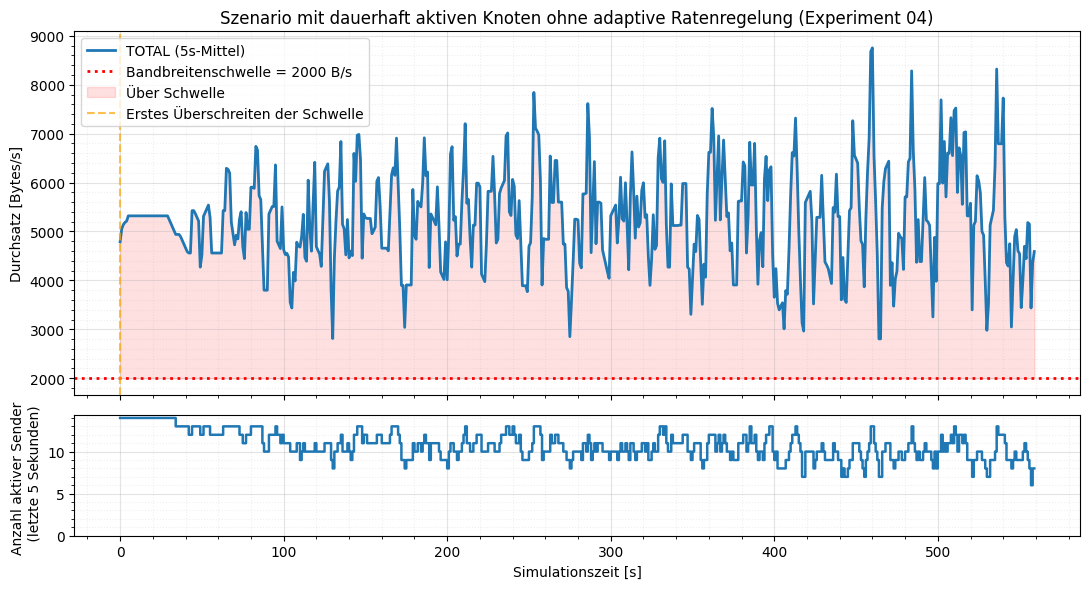

In [121]:
# 1. Logs laden
ROOT_DIR = Path("scenarios")
SCENARIO_NAME = "always"
DATA_KIND = "beacon"
EXPERIMENT_ID = "04"              # <- hier den Durchlauf wählen: "01", "02", "03", "04" ...

# 1) Logs laden (nur der gewählte Durchlauf)
logs_by_node = build_map(ROOT_DIR, SCENARIO_NAME, DATA_KIND, experiment=EXPERIMENT_ID)

# 2) 1s-Bytes/s pro Node
throughput_per_sec_by_node = aggregate_to_seconds(logs_by_node)

# 3) Matrix aller Nodes
throughput_matrix_1s = combine_nodes_per_sec(throughput_per_sec_by_node)

# 4) 5s-Rolling
throughput_matrix_5s = compute_rolling_bytes_per_sec(throughput_matrix_1s, window_s=5)

# 5) Plot
plot_total_with_nodecount_subplot(
    M_roll=throughput_matrix_5s,
    bmax=2000.0,
    titel=f"Szenario mit dauerhaft aktiven Knoten ohne adaptive Ratenregelung (Experiment {EXPERIMENT_ID})",
    fenster_s=5,
    M_per_sec=throughput_matrix_1s,
    out_path=f"plots/{SCENARIO_NAME}_{DATA_KIND}_exp{_normalize_experiment_id(EXPERIMENT_ID)}.png"
)

[OK] Plot gespeichert: plots/always_message_exp01.png


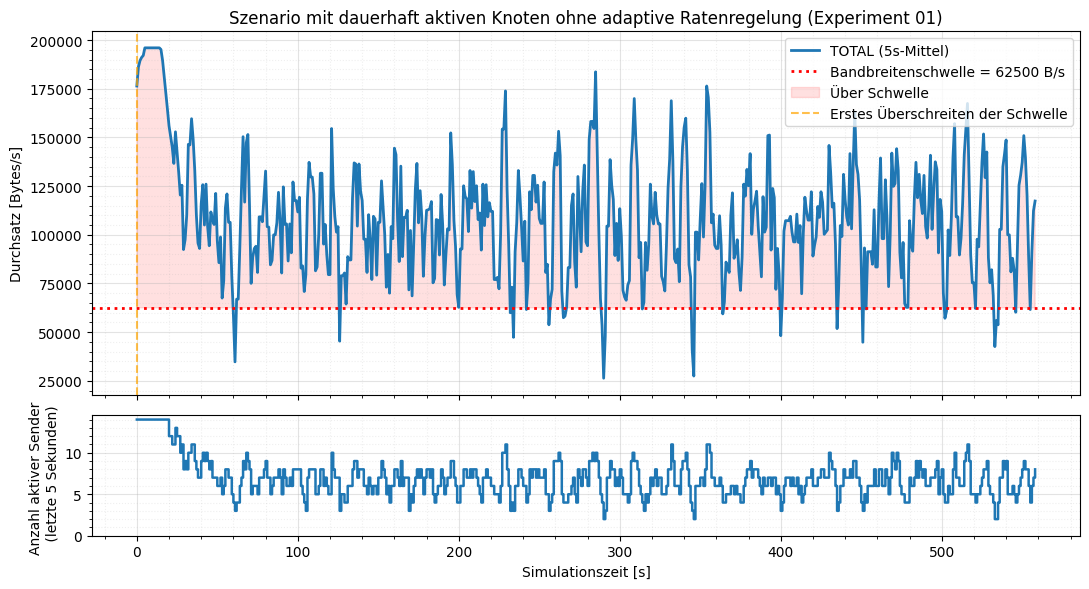

In [116]:
# 1. Logs laden
ROOT_DIR = Path("scenarios")
SCENARIO_NAME = "always"
DATA_KIND = "message"
EXPERIMENT_ID = "01"              # <- hier den Durchlauf wählen: "01", "02", "03", "04" ...

# 1) Logs laden (nur der gewählte Durchlauf)
logs_by_node = build_map(ROOT_DIR, SCENARIO_NAME, DATA_KIND, experiment=EXPERIMENT_ID)

# 2) 1s-Bytes/s pro Node
throughput_per_sec_by_node = aggregate_to_seconds(logs_by_node)

# 3) Matrix aller Nodes
throughput_matrix_1s = combine_nodes_per_sec(throughput_per_sec_by_node)

# 4) 5s-Rolling
throughput_matrix_5s = compute_rolling_bytes_per_sec(throughput_matrix_1s, window_s=5)

# 5) Plot
plot_total_with_nodecount_subplot(
    M_roll=throughput_matrix_5s,
    bmax=62500.0,
    titel=f"Szenario mit dauerhaft aktiven Knoten ohne adaptive Ratenregelung (Experiment {EXPERIMENT_ID})",
    fenster_s=5,
    M_per_sec=throughput_matrix_1s,
    out_path=f"plots/{SCENARIO_NAME}_{DATA_KIND}_exp{_normalize_experiment_id(EXPERIMENT_ID)}.png"
)

## 1.3 Auswertung – Szenario mit dauerhaft aktiven Knoten mit adaptiver Ratenregelung

[OK] Plot gespeichert: plots/always_adaption_beacon_exp01.png


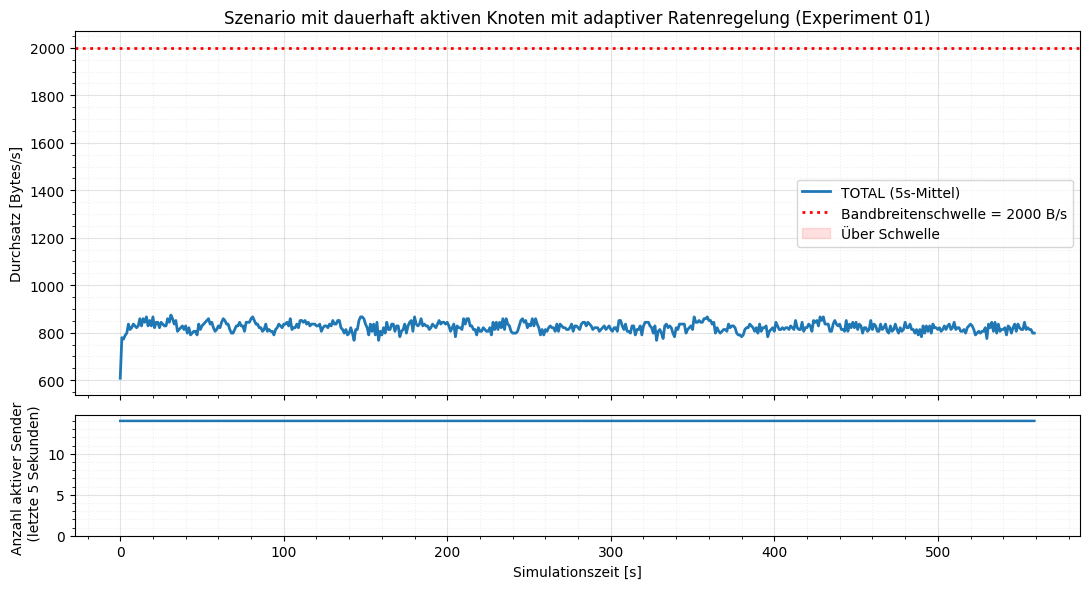

In [117]:
# 1. Logs laden
ROOT_DIR = Path("scenarios")
SCENARIO_NAME = "always_adaption"
DATA_KIND = "beacon"
EXPERIMENT_ID = "01"              # <- hier den Durchlauf wählen: "01", "02", "03", "04" ...

# 1) Logs laden (nur der gewählte Durchlauf)
logs_by_node = build_map(ROOT_DIR, SCENARIO_NAME, DATA_KIND, experiment=EXPERIMENT_ID)

# 2) 1s-Bytes/s pro Node
throughput_per_sec_by_node = aggregate_to_seconds(logs_by_node)

# 3) Matrix aller Nodes
throughput_matrix_1s = combine_nodes_per_sec(throughput_per_sec_by_node)

# 4) 5s-Rolling
throughput_matrix_5s = compute_rolling_bytes_per_sec(throughput_matrix_1s, window_s=5)

# 5) Plot
plot_total_with_nodecount_subplot(
    M_roll=throughput_matrix_5s,
    bmax=2000.0,
    titel=f"Szenario mit dauerhaft aktiven Knoten mit adaptiver Ratenregelung (Experiment {EXPERIMENT_ID})",
    fenster_s=5,
    M_per_sec=throughput_matrix_1s,
    out_path=f"plots/{SCENARIO_NAME}_{DATA_KIND}_exp{_normalize_experiment_id(EXPERIMENT_ID)}.png"
)

[OK] Plot gespeichert: plots/always_adaption_message_exp01.png


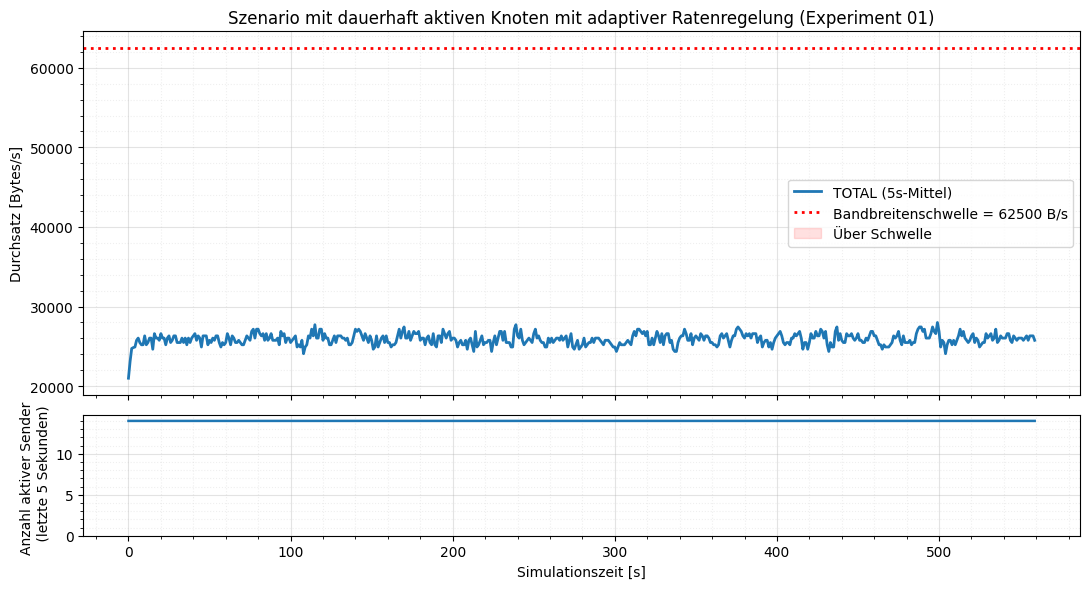

In [118]:
# 1. Logs laden
ROOT_DIR = Path("scenarios")
SCENARIO_NAME = "always_adaption"
DATA_KIND = "message"
EXPERIMENT_ID = "01"              # <- hier den Durchlauf wählen: "01", "02", "03", "04" ...

# 1) Logs laden (nur der gewählte Durchlauf)
logs_by_node = build_map(ROOT_DIR, SCENARIO_NAME, DATA_KIND, experiment=EXPERIMENT_ID)

# 2) 1s-Bytes/s pro Node
throughput_per_sec_by_node = aggregate_to_seconds(logs_by_node)

# 3) Matrix aller Nodes
throughput_matrix_1s = combine_nodes_per_sec(throughput_per_sec_by_node)

# 4) 5s-Rolling
throughput_matrix_5s = compute_rolling_bytes_per_sec(throughput_matrix_1s, window_s=5)

# 5) Plot
plot_total_with_nodecount_subplot(
    M_roll=throughput_matrix_5s,
    bmax=62500.0,
    titel=f"Szenario mit dauerhaft aktiven Knoten mit adaptiver Ratenregelung (Experiment {EXPERIMENT_ID})",
    fenster_s=5,
    M_per_sec=throughput_matrix_1s,
    out_path=f"plots/{SCENARIO_NAME}_{DATA_KIND}_exp{_normalize_experiment_id(EXPERIMENT_ID)}.png"
)